In [4]:
# Importing necessary libraries

import pandas as pd
import nltk

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression

In [5]:
# Loading the dataset

df = pd.read_csv('data/mental_health.csv', index_col=0)
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [36]:
# Display the first few rows of the dataframe

df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [37]:
# Display summary statistics of the dataframe

df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [38]:
# Display information about the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


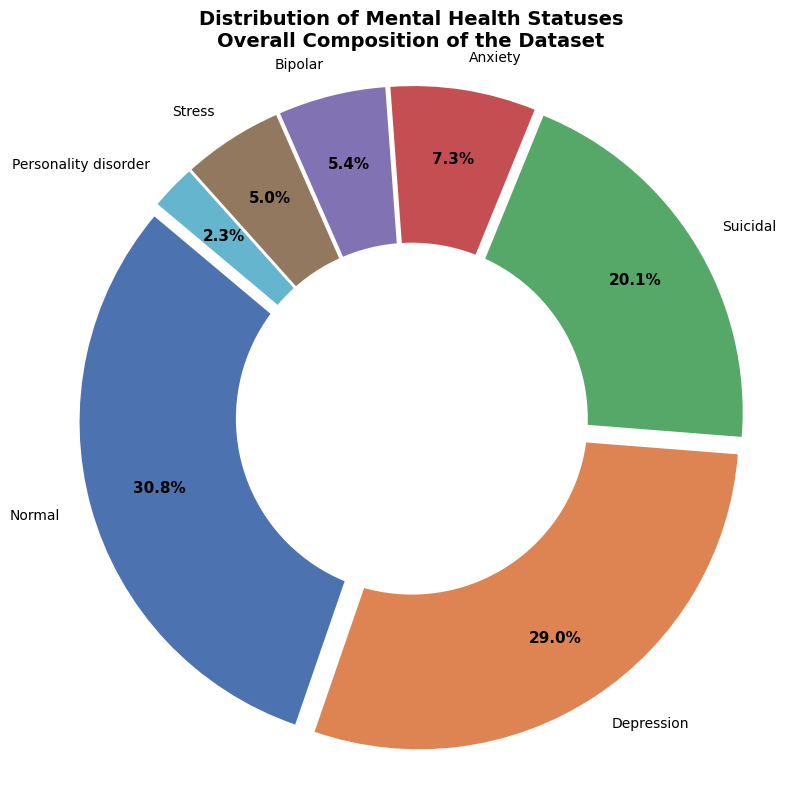

In [39]:
# Visualizing the distribution of mental health statuses

status_counts = df['status'].value_counts()

colors = [
    '#4C72B0',  # blue
    '#DD8452',  # orange
    '#55A868',  # green
    '#C44E52',  # red
    '#8172B3',  # purple
    '#937860',  # brown
    '#64B5CD'   # cyan
]

explode = [0.04] * len(status_counts)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.78,
    shadow=False
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.title(
    'Distribution of Mental Health Statuses\n'
    'Overall Composition of the Dataset',
    fontsize=14,
    weight='bold'
)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [40]:
# Checking for missing values in the dataframe

df.isna().sum()

statement    362
status         0
dtype: int64

In [41]:
# Dropping rows with missing values and checking again for missing values

df.dropna(inplace = True)
df.isna().sum()

statement    0
status       0
dtype: int64

In [42]:
# Selecting a random statement for each mental health status

random_statements = df.groupby('status')['statement'].apply(lambda x: x.sample(n=1).iloc[0])

# Printing the results

for status, statement in random_statements.items():
    print(f"Status: {status}")
    print(f"Statement: {statement}\n")

Status: Anxiety
Statement: Can someone please understand me and give me motivation! Hello everyone I hope you’re okay!

So from January 24th up to know I have fallen back into my anxious state. 

It all started when I went to the big city in January I hadn’t felt anxious in months and I love the city so didn’t expect it. When I was walking off my train all the way down to the shopping centre I felt my legs and they didn’t feel ‘normal’ not weak but not strong and I was really aware of them and felt like my legs would just fail to walk and I’d fall over. The more I walked the more I started to stress out it got to the point where I felt dizzy and a bit lightheaded cause I was panicking and BOOM it hit I’m think OMG am I going to pass out ! I started to panic and think maybe it was diabetes but I’m a slim 22 year old male with no health conditions but in the moment I was panicking it was horrible so derealised and the fear of impending doom ! And then 3 days later I imagine because my ne

In [43]:
# Analyzing the length of statements

df['num_of_characters'] = df['statement'].str.len()
df['num_of_sentences'] = df['statement'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Displaying descriptive statistics for the new columns

description = df[['num_of_characters', 'num_of_sentences']].describe()
description

,num_of_characters,num_of_sentences
count,52681.000000,52681.000000
mean,578.713863,6.280215
std,846.269078,10.688388
min,2.000000,1.000000
25%,80.000000,1.000000
50%,317.000000,3.000000
75%,752.000000,8.000000
max,32759.000000,1260.000000


In [44]:
# Displaying the entire data with new columns (num_of_characters, num_of_sentences)

df

,statement,status,num_of_characters,num_of_sentences
0,oh my gosh,Anxiety,10,1
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,2
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,2
3,I've shifted my focus to something else but I'...,Anxiety,61,1
4,"I'm restless and restless, it's been a month n...",Anxiety,72,2
...,...,...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,1766,16
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,1012,12
53040,Is there any way to sleep better? I can't slee...,Anxiety,85,2
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,401,6


In [45]:
# Splitting the dataset into training and testing sets

X = df["statement"]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Encoding the target labels

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [47]:
# Encoding the text data using TF-IDF Vectorization

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000) 

X_train = vectorizer.fit_transform(X_train) 
X_test = vectorizer.transform(X_test)

In [48]:
# Training a Logistic Regression model

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [49]:
# Making predictions on the test set

y_pred = log_reg.predict(X_test)

In [50]:
# Evaluating the model's performance

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.7778305020404289

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.79      0.80      0.80       768
             Bipolar       0.74      0.81      0.78       556
          Depression       0.81      0.63      0.71      3081
              Normal       0.89      0.92      0.91      3269
Personality disorder       0.54      0.73      0.63       215
              Stress       0.52      0.72      0.60       517
            Suicidal       0.69      0.77      0.73      2131

            accuracy                           0.78     10537
           macro avg       0.71      0.77      0.74     10537
        weighted avg       0.79      0.78      0.78     10537



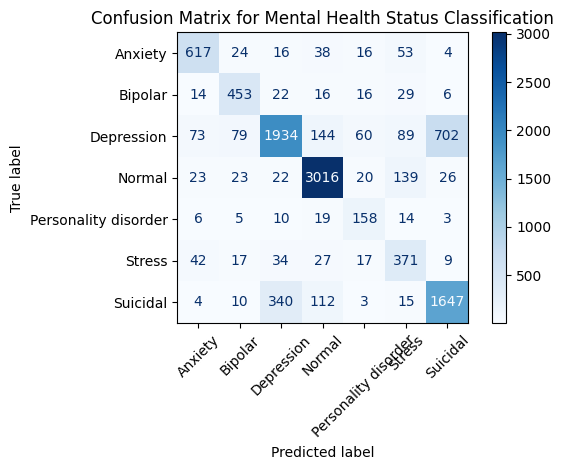

In [51]:
# Visualizing the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix for Mental Health Status Classification")
plt.tight_layout()
plt.show()